In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc_context
import matplotlib.patheffects as path_effects
import sunpy
import sunpy.map
from sunpy.coordinates import propagate_with_solar_surface
import astropy
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from astropy.io import fits, ascii
from astropy.time import Time
from astropy.convolution import convolve, Gaussian2DKernel
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from sunkit_magex import pfss as pfsspy
import sunkit_magex.pfss.utils
import sunkit_magex.pfss.tracing as tracing


import h5py 
import dask.array as da 
from ndcube import NDCube

In [6]:
# based on mag2pfsspy https://github.com/STBadman/magnetograms2pfsspy/blob/master/mag2pfsspy.py#L12
# written by Samuel Badman, but updated to fit pfsspy 1.2.0
# pfsspy is archived at this moment, but I still use it when the succeeding sunkit-magex is under development
# def extract_br(m):
# 	br = m.data
# 	br = br - np.nanmean(br)
# 	# GONG maps have their LH edge at -180deg, so roll to get it at 0deg
# 	br = np.roll(br, int((m.meta['CRVAL1'] + 180)/np.abs(m.meta['cdelt1'])), axis=1)
# 	br = np.nan_to_num(br)
# 	return br*1e5 # Gauss to nT

def hmi2pfsspy(filepath,rss=2.5,nr=60,ret_magnetogram=False,resample=None, map_type='daily',
			   ext=0): 
	if map_type == 'daily':
		hmi_fits_data = fits.getdata(filepath,ext=ext)
		hmi_fits_header = fits.getheader(filepath,ext=ext)
		hmi_fits_header['CUNIT2'] = 'Sine Latitude'
		# for card in ['HGLN_OBS','CRDER1','CRDER2','CSYSER1','CSYSER2'] :
		# 	hmi_fits_header[card] = 0

		hmi_fits_header['T_OBS'] = hmi_fits_header['T_OBS'][:-8]+"_TAI"

		hmi_fits_data = np.nan_to_num(hmi_fits_data, nan=0.0)
		# since the cdelt1 is flipped, one should also update the crval1 either through sunpy.L0 (like sam) or manually from FITS header
		# hmi_fits_header['CRVAL1'] = 120 + sun.L0(time=hmi_fits_header['T_OBS']).to_value(u.deg)
		hmi_fits_header['CRVAL1'] = (2262*360*u.deg - \
		(hmi_fits_header["CRVAL1"] + hmi_fits_header["NAXIS1"]*hmi_fits_header["CDELT1"])*u.deg).to_value(u.deg)
		# print(hmi_fits_header['CRVAL1'])

		hmi_map = sunpy.map.sources.HMISynopticMap(hmi_fits_data,hmi_fits_header)
	elif map_type == 'cr':
		hmi_fits_data = fits.getdata(filepath,ext=ext)
		hmi_fits_header = fits.getheader(filepath,ext=ext)
		hmi_map = sunpy.map.Map(hmi_fits_data, hmi_fits_header)
		hmi_map = sunpy.map.Map(np.nan_to_num(hmi_map.data, nan=0.0), hmi_map.meta)
		
	if resample is not None: 
		hmi_map_size = hmi_map.data.shape
		x_superpixel = int(hmi_map_size[1]/resample[0].value)
		y_superpixel = int(hmi_map_size[0]/resample[1].value)
		x_std = x_superpixel
		y_std = y_superpixel

		kernel = Gaussian2DKernel(x_stddev=x_std, y_stddev=y_std)
		hmi_map_conv = convolve(hmi_map.data, kernel, boundary='extend')
		hmi_map_conv = sunpy.map.sources.HMISynopticMap(hmi_map_conv, hmi_fits_header)
		hmi_map = hmi_map_conv.superpixel([x_superpixel, y_superpixel]*u.pix, func=np.nanmean)
	
	# br_hmi = extract_br(hmi_map)
	if ret_magnetogram:
		return hmi_map
	pfss_input = pfsspy.Input(hmi_map, nr, rss,)

	pfss_output = pfsspy.pfss(pfss_input)
	return pfss_output

In [7]:
hmi_daily_synoptic_map = hmi2pfsspy("../../data/hmi/synoptic/hmi.Mrdailysynframe_720s.20221024_120000_TAI.data.fits", 
                            resample=[1440,720]*u.pix,ret_magnetogram=True, map_type='daily')

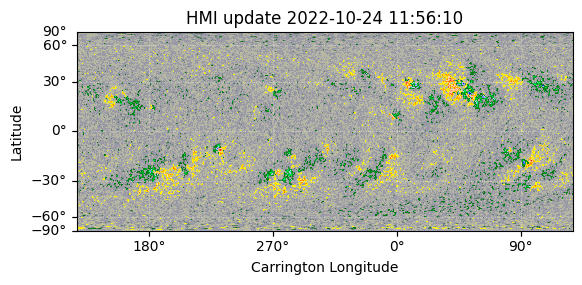

In [8]:
hmi_daily_synoptic_map.plot()

In [39]:
pfss_output = hmi2pfsspy("../../data/hmi/synoptic/hmi.Mrdailysynframe_720s.20221024_120000_TAI.data.fits",
                        resample=[720,360]*u.pix,nr=100, rss=2.5)

In [10]:
def trace_flines(pfss_output, seed, max_steps='auto'):
    tracer = tracing.FortranTracer(max_steps=max_steps)
    with propagate_with_solar_surface():
        flines = tracer.trace(seed, pfss_output)

    return flines

In [24]:
aia_171_map = sunpy.map.Map("../../data/aia/171/aia.lev1_euv_12s.2022-10-24T192027Z.171.image.fits")
aia_171_map = aia_171_map.submap(bottom_left=SkyCoord(-500*u.arcsec, 100*u.arcsec, frame=aia_171_map.coordinate_frame),
                                top_right=SkyCoord(-300*u.arcsec, 300*u.arcsec, frame=aia_171_map.coordinate_frame))

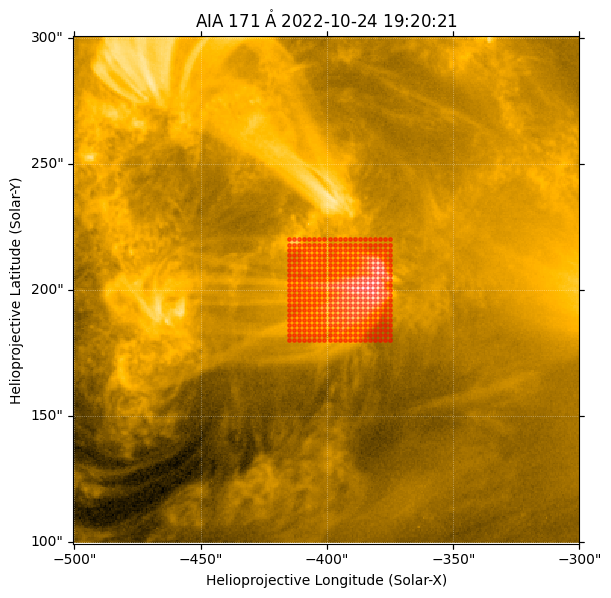

In [50]:
fig = plt.figure(figsize=(6,6), layout="constrained")
ax = fig.add_subplot(projection=aia_171_map)
aia_171_map.plot(axes=ax)

seed_lon, seed_lat = np.meshgrid(np.linspace(-415,-375,21), np.linspace(180,220,21))
seed_coord = SkyCoord(seed_lon.ravel()*u.arcsec, seed_lat.ravel()*u.arcsec, frame=aia_171_map.coordinate_frame)

ax.plot_coord(seed_coord, marker='.',color='red',markersize=5,alpha=0.5, lw=0)

In [51]:
flines_traced = trace_flines(pfss_output, seed_coord, max_steps=20000)

/cluster/home/zhuyin/sunpy_env/lib/python3.11/site-packages/sunkit_magex/pfss/tracing.py:181: UserWarning: At least one field line ran out of steps during tracing.
You should probably increase max_steps (currently set to 20000) and try again.
  warnings.warn(


In [52]:
flines_traced[0].coords

<SkyCoord (HeliographicCarrington: obstime=2022-10-24T11:55:33.000, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-10-24T11:55:33.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (-0.02024932, 5.11234903, 1.48815773e+11)>): (lon, lat, radius) in (deg, deg, m)
    [(158.32299771, 15.78866611, 6.95811080e+08),
     (157.88054837, 15.49919052, 6.96161725e+08),
     (157.39654307, 15.29001308, 6.96000000e+08),
     (156.88936968, 15.15228475, 6.95797827e+08),
     (156.66515158, 15.07599786, 6.98837521e+08),
     (156.14607012, 15.04632346, 6.98007803e+08),
     (155.6402993 , 15.09238179, 6.96424104e+08),
     (155.42551498, 15.10615761, 6.98567638e+08)]>

In [53]:
def get_loop_length(line):
    c = line.coords.cartesian.xyz
    s = np.append(0., np.linalg.norm(np.diff(c.value, axis=1), axis=0).cumsum()) * c.unit
    return np.diff(s).sum()

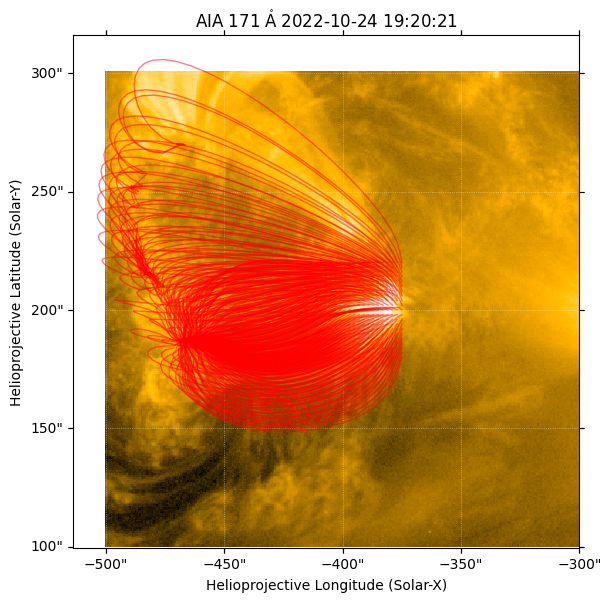

In [55]:
fig = plt.figure(figsize=(6,6), layout="constrained")
ax = fig.add_subplot(projection=aia_171_map)
aia_171_map.plot(axes=ax)

# ax.plot_coord(seed_coord, marker='.',color='red',markersize=5,alpha=0.5, lw=0)

with propagate_with_solar_surface():
    for fline, seed in zip(flines_traced, seed_coord):
        # print(get_loop_length(fline))
        if get_loop_length(fline) > 1 * u.Mm:
            if fline.is_open:
                ax.plot_coord(fline.coords[:], color='#89c3eb', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='#89c3eb', markersize=5,alpha=0.5, lw=0)
            else:
                ax.plot_coord(fline.coords[:], color='red', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='red', markersize=5,alpha=0.5, lw=0)

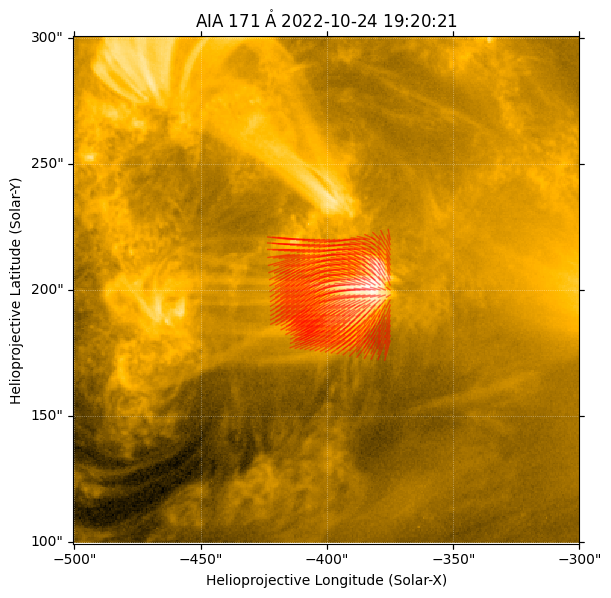

In [56]:
fig = plt.figure(figsize=(6,6), layout="constrained")
ax = fig.add_subplot(projection=aia_171_map)
aia_171_map.plot(axes=ax)

# ax.plot_coord(seed_coord, marker='.',color='red',markersize=5,alpha=0.5, lw=0)

with propagate_with_solar_surface():
    for fline, seed in zip(flines_traced, seed_coord):
        # print(get_loop_length(fline))
        if get_loop_length(fline) > 1 * u.Mm:
            if fline.is_open:
                ax.plot_coord(fline.coords[:2], color='#89c3eb', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='#89c3eb', markersize=5,alpha=0.5, lw=0)
            else:
                ax.plot_coord(fline.coords[:2], color='red', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='red', markersize=5,alpha=0.5, lw=0)

In [14]:
file_hri_pr_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_pr.hdf5")
hri_pr_set = file_hri_pr_dset["hrieuv_img"]
hri_pr_da = da.from_array(hri_pr_set, chunks=(1, (4096 - 128*2)//8, (4096 - 128*2)//8))


file_hri_pr_noproj_dset = h5py.File("../../data/pid_1_123_aux/plot_ready/HRIEUV_noproj_pr.hdf5")
hri_pr_noproj_array = file_hri_pr_noproj_dset["hrieuv_noproj_img"][:]
hrieuv_no_proj_extent = np.load("../../data/pid_1_123_aux/plot_ready/hrieuv_no_proj_extent.npy")
hrieuv_nocrop_noproj_wcs = WCS(fits.getheader("../../data/pid_1_123_aux/plot_ready/hri_nocrop_noproj_wcs.fits",
                                        ignore_missing_simple=True))
hrieuv_noproj_wcs = hrieuv_nocrop_noproj_wcs[hrieuv_no_proj_extent[1]:hrieuv_no_proj_extent[3] + 1,
                                hrieuv_no_proj_extent[0]:hrieuv_no_proj_extent[2] + 1]

In [17]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((8,8))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [63]:
file_Hbeta_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_pr.hdf5")
Hbeta_pr_set = file_Hbeta_pr["vbi_img"]
Hbeta_pr_da = da.from_array(Hbeta_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Hbeta_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Hbeta_BJOLO_date_avg.txt")["DATE-AVG"])

file_Halpha_pr = h5py.File("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_pr.hdf5")
Halpha_pr_set = file_Halpha_pr["vbi_img"]
Halpha_pr_da = da.from_array(Halpha_pr_set, chunks=(1, 4096 - 128*2, 4096 - 128*2))
Halpha_date_obs = Time(ascii.read("../../data/pid_1_123_aux/plot_ready/Halpha_BLZNL_date_avg.txt")["DATE-AVG"])

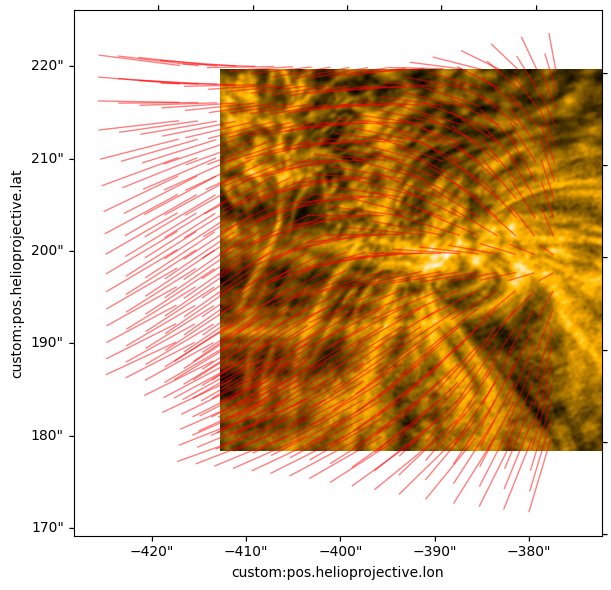

In [57]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop_rebin.wcs)
ax.imshow(hri_pr_da[181,:,:], origin="lower", cmap="sdoaia171")

with propagate_with_solar_surface():
    for fline, seed in zip(flines_traced, seed_coord):
        # print(get_loop_length(fline))
        if get_loop_length(fline) > 1 * u.Mm:
            if fline.is_open:
                ax.plot_coord(fline.coords[:2], color='#89c3eb', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='#89c3eb', markersize=5,alpha=0.5, lw=0)
            else:
                ax.plot_coord(fline.coords[:2], color='red', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='red', markersize=5,alpha=0.5, lw=0)

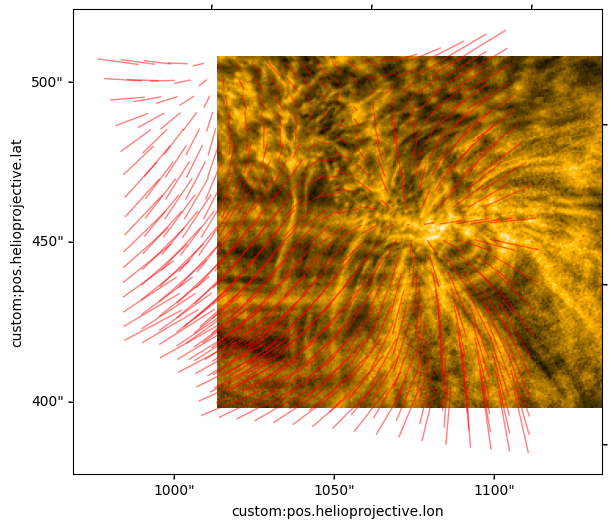

In [59]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=hrieuv_noproj_wcs)
ax.imshow(hri_pr_noproj_array[181,:,:], origin="lower", cmap="sdoaia171")

with propagate_with_solar_surface():
    for fline, seed in zip(flines_traced, seed_coord):
        # print(get_loop_length(fline))
        if get_loop_length(fline) > 1 * u.Mm:
            if fline.is_open:
                ax.plot_coord(fline.coords[:2], color='#89c3eb', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='#89c3eb', markersize=5,alpha=0.5, lw=0)
            else:
                ax.plot_coord(fline.coords[:2], color='red', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='red', markersize=5,alpha=0.5, lw=0)

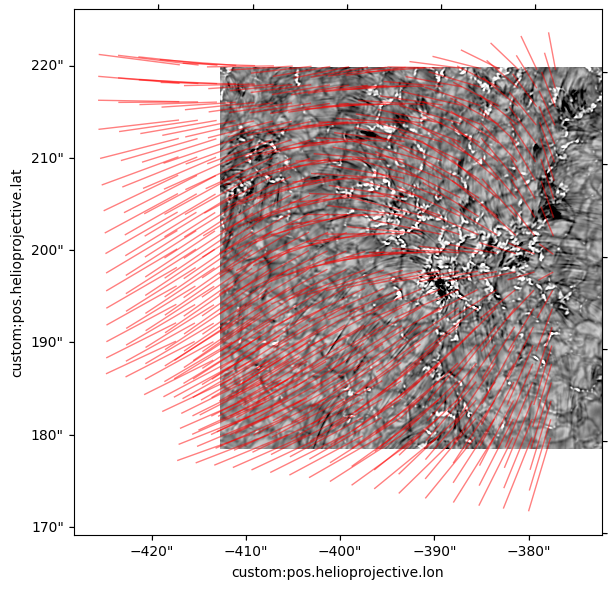

In [66]:
fig = plt.figure(figsize=(6,6), layout="constrained")

ax = fig.add_subplot(111, projection=dkist_vbi_target_cube_crop.wcs)
ax.imshow(Halpha_pr_da[100,:,:], origin="lower", cmap="Greys_r",
          norm=ImageNormalize(vmin=0,vmax=1))

with propagate_with_solar_surface():
    for fline, seed in zip(flines_traced, seed_coord):
        # print(get_loop_length(fline))
        if get_loop_length(fline) > 1 * u.Mm:
            if fline.is_open:
                ax.plot_coord(fline.coords[:2], color='#89c3eb', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='#89c3eb', markersize=5,alpha=0.5, lw=0)
            else:
                ax.plot_coord(fline.coords[:2], color='red', linewidth=1,alpha=0.5)
                # ax.plot_coord(seed, marker='.', color='red', markersize=5,alpha=0.5, lw=0)